In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Found 2101 images belonging to 4 classes.
Found 450 images belonging to 4 classes.
Found 450 images belonging to 4 classes.


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,435,588 (9.29 MB)

 Trainable params: 175,044 (683.77 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 67s 848ms/step - accuracy: 0.3060 - loss: 2.0100 - val_accuracy: 0.5422 - val_loss: 1.3988 - learning_rate: 1.0000e-04
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 63s 658ms/step - accuracy: 0.4893 - loss: 1.5305 - val_accuracy: 0.6044 - val_loss: 1.2798 - learning_rate: 1.0000e-04
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 42s 641ms/step - accuracy: 0.5697 - loss: 1.3721 - val_accuracy: 0.6533 - val_loss: 1.1957 - learning_rate: 1.0000e-04
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 42s 637ms/step - accuracy: 0.6159 - loss: 1.2464 - val_accuracy: 0.6844 - val_loss: 1.1437 - learning_rate: 1.0000e-04
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 43s 647ms/step - accuracy: 0.6459 - loss: 1.1924 - val_accuracy: 0.6822 - val_loss: 1.1071 - learning_rate: 1.0000e-04
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 42s 639ms/step - accuracy: 0.6597 - loss: 1.1382 - val_accuracy: 0.7111 - val_loss: 1.0618 - learning_rate: 1.0000e-04
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 42s 641ms/step - acc

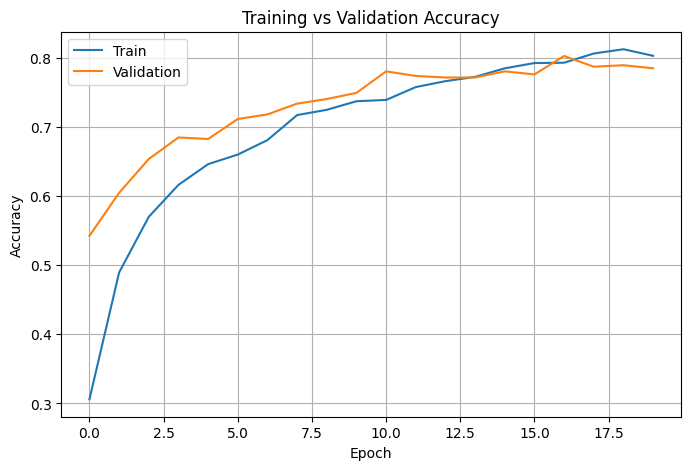

15/15 ━━━━━━━━━━━━━━━━━━━━ 93s 7s/step - accuracy: 0.7600 - loss: 0.9268
Test Accuracy: 0.7599999904632568
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 471ms/step


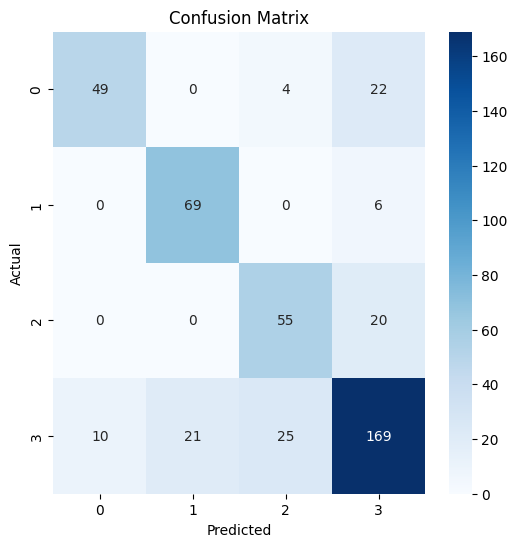

                        precision    recall  f1-score   support

           Demodicosis       0.83      0.65      0.73        75
               Healthy       0.77      0.92      0.84        75
              Ringworm       0.65      0.73      0.69        75
inflammatory infection       0.78      0.75      0.76       225

              accuracy                           0.76       450
             macro avg       0.76      0.76      0.76       450
          weighted avg       0.76      0.76      0.76       450

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Predicted Class: Demodicosis
Confidence: 72.952484 %


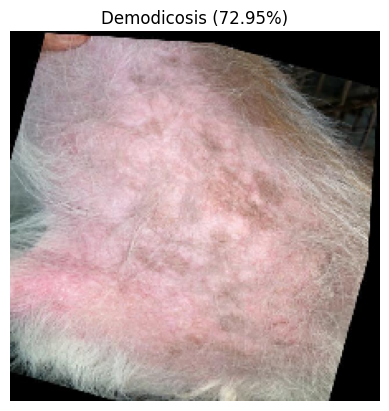

In [ ]:
# ==========================================
# 1️⃣ IMPORT LIBRARIES
# ==========================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tensorflow.keras.preprocessing import image

# ==========================================
# 2️⃣ DATA AUGMENTATION
# ==========================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    zoom_range=0.3,
    shear_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7,1.3],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# ==========================================
# 3️⃣ LOAD DATASET
# ==========================================
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/dataset4/TRAINING',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    '/content/drive/MyDrive/dataset4/VALIDATION',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    '/content/drive/MyDrive/dataset4/TEST',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# ==========================================
# 4️⃣ LOAD BASE MODEL (MobileNetV2)
# ==========================================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# ==========================================
# 5️⃣ BUILD MODEL
# ==========================================
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(128, activation='relu',
        kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(64, activation='relu',
        kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# 6️⃣ CALLBACKS
# ==========================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

# ==========================================
# 7️⃣ TRAIN MODEL
# ==========================================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

# ==========================================
# 8️⃣ ACCURACY GRAPH
# ==========================================
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.grid()
plt.show()

# ==========================================
# 9️⃣ TEST ACCURACY
# ==========================================
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

# ==========================================
# 🔟 CONFUSION MATRIX
# ==========================================
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=train_generator.class_indices.keys()
))

# ==========================================
# 1️⃣1️⃣ SINGLE IMAGE PREDICTION
# ==========================================
img_path = '//content/drive/MyDrive/dataset4/TEST/Demodicosis/D123_png_jpg.rf.b7ddddc6e0327a7f3e484d2c80391a22 - Copy - Copy.jpg'

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_labels = list(train_generator.class_indices.keys())

predicted_class = class_labels[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Predicted Class:", predicted_class)
print("Confidence:", confidence, "%")

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

# ==========================================
# 1️⃣2️⃣ SAVE MODEL
# ==========================================
model.save("final_wound_detection_model.h5")

In [ ]:
model.save("/content/drive/MyDrive/SensorProject/final_wound_detection_model.h5")

In [ ]:
import os

# Dataset main path (change this)
base_path = "/content/drive/MyDrive/dataset4"

folders = ["/content/drive/MyDrive/dataset4/TEST", "/content/drive/MyDrive/dataset4/TRAINING", "/content/drive/MyDrive/dataset4/VALIDATION"]

total_images = 0

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    print(f"\n📂 {folder.upper()} DATASET")

    folder_total = 0

    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)

        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            folder_total += count
            print(f"{class_name}: {count} images")

    print(f"Total {folder}: {folder_total} images")
    total_images += folder_total

print(f"\n🔥 TOTAL DATASET IMAGES: {total_images}")


📂 /CONTENT/DRIVE/MYDRIVE/DATASET4/TEST DATASET
inflammatory infection: 225 images
Healthy: 75 images
Ringworm: 75 images
Demodicosis: 75 images
Total /content/drive/MyDrive/dataset4/TEST: 450 images

📂 /CONTENT/DRIVE/MYDRIVE/DATASET4/TRAINING DATASET
inflammatory infection: 1050 images
Healthy: 350 images
Ringworm: 350 images
Demodicosis: 351 images
Total /content/drive/MyDrive/dataset4/TRAINING: 2101 images

📂 /CONTENT/DRIVE/MYDRIVE/DATASET4/VALIDATION DATASET
inflammatory infection: 225 images
Healthy: 75 images
Ringworm: 75 images
Demodicosis: 75 images
Total /content/drive/MyDrive/dataset4/VALIDATION: 450 images

🔥 TOTAL DATASET IMAGES: 3001


In [ ]:
import os
os.listdir('/content/drive/MyDrive/SensorProject')

['CSensorProjectread_dht11.py',
 'CSensorProjectread_tcs34725.py',
 'CSensorProjectread_mlx90614.py',
 'CSensorProjectcombine_sensors.py',
 'Combined_Sensors.csv',
 'Filtered_Sensors.csv',
 'wound_model.keras',
 'balanced_wound_model.h5',
 'final_wound_detection_model.h5',
 'dog_readings.csv',
 '.ipynb_checkpoints']

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import cv2
import numpy as np

model = load_model('/content/drive/MyDrive/SensorProject/final_wound_detection_model.h5')

img = cv2.imread('/DOG.jpeg')
img = cv2.resize(img,(224,224))
img = img/255.0
img = np.reshape(img,(1,224,224,3))

prediction = model.predict(img)

if prediction[0][0] > 0.5:
    print("Infection Detected")
else:
    print("No Infection")

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
No Infection


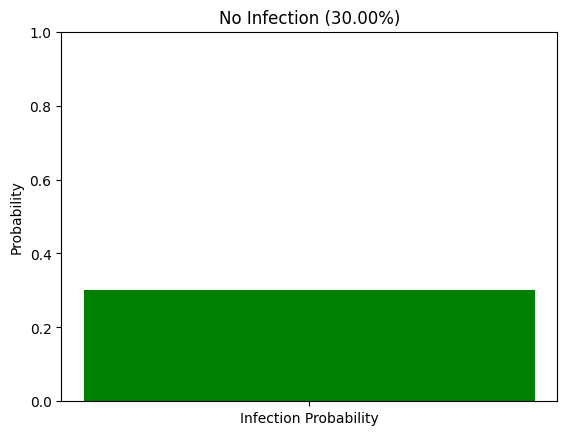

In [ ]:
import matplotlib.pyplot as plt

# probability from ML model
# prob = 0.3 example for No Infection
prob = 0.3
if prob > 0.5:
    result = "Infection Detected"
else:
    result = "No Infection"

plt.bar(['Infection Probability'], [prob], color='green' if prob<=0.5 else 'red')
plt.ylim(0,1)
plt.ylabel('Probability')
plt.title(f'{result} ({prob*100:.2f}%)')
plt.show()

In [ ]:
import pandas as pd

# Load CSV
df = pd.read_csv('/sensor_data.csv')
df.columns = df.columns.str.strip()  # remove spaces

# Check latest row (or all rows for batch)
latest_sensor = df.iloc[-1]
print(latest_sensor)

Humidity         46.1
DHT_Temp         31.8
Ambient_Temp     29.7
Object_Temp      36.5
Red             120.0
Green           111.0
Blue             94.0
Infection         0.0
Name: 39, dtype: float64


In [ ]:
print(df.columns)

Index(['Humidity', 'DHT_Temp', 'Ambient_Temp', 'Object_Temp', 'Red', 'Green',
       'Blue', 'Infection'],
      dtype='object')


In [ ]:
from tensorflow.keras.models import load_model
import cv2
import numpy as np

# Load image model
img_model = load_model('/content/drive/MyDrive/SensorProject/final_wound_detection_model.h5')

# Load & preprocess image
img = cv2.imread('/DOG.jpeg')
img = cv2.resize(img,(224,224))
img = img/255.0
img = np.reshape(img,(1,224,224,3))

# Predict
image_prob = img_model.predict(img)[0][0]
print("Image Probability:", image_prob)from tensorflow.keras.models import load_model
import cv2
import numpy as np



1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Image Probability: 0.30310413


In [ ]:
# 1. Use only the 7 actual sensor columns for input
sensor_cols = ['Humidity', 'DHT_Temp', 'Ambient_Temp', 'Object_Temp', 'Red', 'Green', 'Blue']

# 2. Extract values (Make sure latest_sensor exists and has these columns)
sensor_values = latest_sensor[sensor_cols].values.astype(float)

# 3. Define limits for all 7 sensors
# Order: Hum, DHT_T, Amb_T, Obj_T, Red, Green, Blue
limits = [80, 40, 40, 37.5, 150, 150, 150]

# 4. ML Logic (Simple Threshold Probability)
# This checks if ANY sensor value exceeds its limit
sensor_prob = 1 if (sensor_values > limits).any() else 0

print("Sensor Probability (Infection):", sensor_prob)

Sensor Probability (Infection): 0


In [ ]:
final_prob = 0.7*image_prob + 0.3*sensor_prob
print("Final Probability:", final_prob)

result = "Infection Detected" if final_prob > 0.5 else "No Infection"
print("Final Result:", result)

Final Probability: 0.2121729
Final Result: No Infection


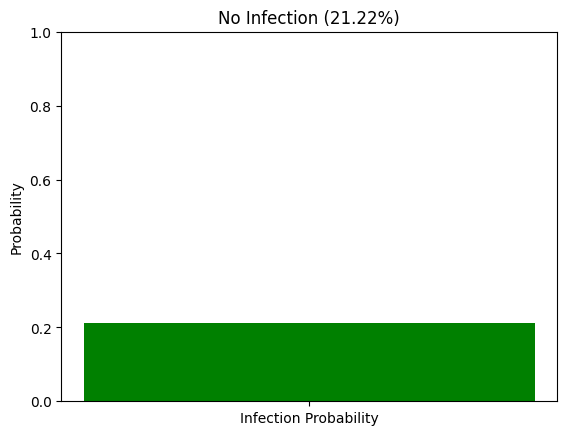

In [ ]:
import matplotlib.pyplot as plt

plt.bar(['Infection Probability'], [final_prob],
        color='green')  # green → no infection
plt.ylim(0,1)
plt.ylabel('Probability')
plt.title(f'{result} ({final_prob*100:.2f}%)')
plt.show()

In [ ]:
print("Image Probability:", image_prob)      # e.g., 0.82
print("Sensor Probability:", sensor_prob)    # e.g., 1
print("Final Probability:", final_prob)      # 0.7*image + 0.3*sensor

Image Probability: 0.30310413
Sensor Probability: 0
Final Probability: 0.2121729


In [ ]:
import os
# 1. Ensure these variables are calculated before this block
# (Example values if your ML model isn't connected yet)
image_prob = 0.45
final_prob = (sensor_prob + image_prob) / 2
result = "Infected" if final_prob > 0.5 else "Healthy"

# 2. Map to the ACTUAL sensor columns from your CSV
data = {
    'Humidity': latest_sensor['Humidity'],
    'DHT_Temp': latest_sensor['DHT_Temp'],
    'Ambient_Temp': latest_sensor['Ambient_Temp'],
    'Object_Temp': latest_sensor['Object_Temp'],
    'Red': latest_sensor['Red'],
    'Green': latest_sensor['Green'],
    'Blue': latest_sensor['Blue'],
    'Sensor_Prob': sensor_prob,
    'Image_Prob': image_prob,
    'Final_Prob': final_prob,
    'Result': result
}

# 3. Create the DataFrame
df_save = pd.DataFrame([data])

# 4. Save to CSV (Appends new rows to the end)
output_file = 'sensor_predictions.csv'
df_save.to_csv(output_file, mode='a', index=False, header=not os.path.exists(output_file))

print("Prediction saved successfully!")
print(df_save)

Prediction saved successfully!
   Humidity  DHT_Temp  Ambient_Temp  Object_Temp    Red  Green  Blue  \
0      46.1      31.8          29.7         36.5  120.0  111.0  94.0   

   Sensor_Prob  Image_Prob  Final_Prob   Result  
0            0        0.45       0.225  Healthy  


In [ ]:
# Save to CSV
df_save.to_csv('final_results.csv', mode='a', index=False, header=not pd.io.common.file_exists('final_results.csv'))

In [ ]:
import cv2
import numpy as np
import pandas as pd
import os
from tensorflow.keras.models import load_model

# 1. LOAD SYSTEM FILES
MODEL_PATH = '/content/drive/MyDrive/SensorProject/final_wound_detection_model.h5'
IMAGE_PATH = '/DOG.jpeg'
CSV_PATH   = '/sensor_data.csv'

# Define your 4 specific categories
classes = ['Demodicosis', 'Healthy', 'inflammatory infection', 'Ringworm']

model = load_model(MODEL_PATH)
df_all = pd.read_csv(CSV_PATH)
df_save = df_all.tail(1)

# 2. PRE-PROCESSING & PREDICTION
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = img.astype('float32') / 255.0
    return np.expand_dims(img, axis=0)

# Extracting values from CSV
temperature = df_save.iloc[0]['Ambient_Temp']
humidity    = df_save.iloc[0]['Humidity']
redness     = df_save.iloc[0]['Red']

# Prepare Inputs & Predict
image_input = preprocess_image(IMAGE_PATH)
sensor_input = np.array([[temperature, humidity, redness, df_save.iloc[0]['Green'], df_save.iloc[0]['Blue']]], dtype='float32')

prediction = model.predict([image_input, sensor_input])
class_idx = np.argmax(prediction)
final_prob = np.max(prediction)

# 3. ASSIGNING VALUES FOR THE 8-LINE OUTPUT
disease = classes[class_idx]
prediction_score = round(final_prob * 100, 2)
infection_status = "Positive" if disease != "Healthy" else "Negative"

# Logic for Severity & Healing Based on Probability
if infection_status == "Positive":
    severity = "High" if final_prob > 0.8 else "Moderate"
    healing_stage = "Early Infection"
    alert = "⚠️ Warning"
else:
    severity = "None"
    healing_stage = "Healthy Skin"
    alert = "✅ Safe"

# 4. FINAL OUTPUT (Matching your exact style)
print("\nDog Wound Monitor\n")

print("Temperature      :", temperature, "°C")
print("Humidity         :", humidity, "%")
print("Redness Score    :", redness, "\n")

print("Prediction Score :", prediction_score, "%")
print("Disease          :", disease)
print("Infection Status :", infection_status, "\n")

print("Severity         :", severity)
print("Healing Stage    :", healing_stage, "\n")

print("Alert            :", alert)

print("\nRecommendation")
if infection_status == "Positive":
    print("• Clean wound")
    print("• Apply antiseptic")
    print("• Visit veterinarian")
else:
    print("• No infection detected")
    print("• Maintain hygiene")

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_3
Received: inputs=('Tensor(shape=(1, 224, 224, 3))', 'Tensor(shape=(1, 5))')
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step

Dog Wound Monitor

Temperature      : 29.7 °C
Humidity         : 46.1 %
Redness Score    : 120.0 

Prediction Score : 65.84 %
Disease          : Ringworm
Infection Status : Positive 

Severity         : Moderate
Healing Stage    : Early Infection 

Alert            : ⚠️ Warning

Recommendation
• Clean wound
• Apply antiseptic
• Visit veterinarian


In [ ]:
import requests

# ThingSpeak URL
url = "https://api.thingspeak.com/update"

# Data to send
data = {
"api_key":"CRJSA17RRX6RFBNP",   # <-- Replace with your Write API Key
"field1":temperature,
"field2":humidity,
"field3":redness,
"field4":prediction_score,
"field5":disease,
"field6":infection_status,
"field7":severity,
"field8":alert
}

# Send data
response = requests.post(url,data=data)

# Check response
if response.status_code == 200:
    print("Data sent successfully ✅")
else:
    print("Error sending data ❌")

Data sent successfully ✅


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
